Saving train.csv to train (1).csv


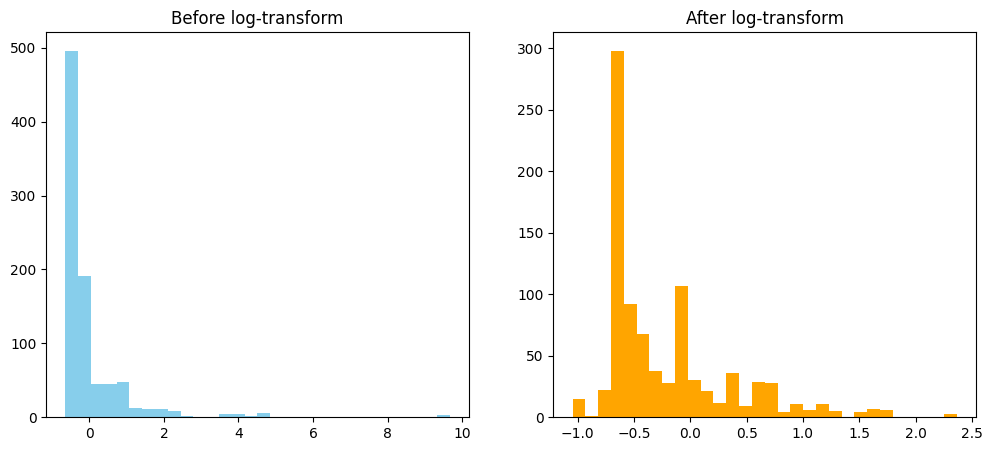

                 PassengerId  Survived    Pclass       Age     SibSp  \
PassengerId         1.000000 -0.005007 -0.035144  0.033207 -0.057527   
Survived           -0.005007  1.000000 -0.338481 -0.069809 -0.035322   
Pclass             -0.035144 -0.338481  1.000000 -0.331339  0.083081   
Age                 0.033207 -0.069809 -0.331339  1.000000 -0.232625   
SibSp              -0.057527 -0.035322  0.083081 -0.232625  1.000000   
Parch              -0.001652  0.081629  0.018443 -0.179191  0.414838   
Fare                0.012658  0.257307 -0.549500  0.091566  0.159651   
Sex_female         -0.042939  0.543351 -0.131900 -0.084153  0.114631   
Sex_male            0.042939 -0.543351  0.131900  0.084153 -0.114631   
Embarked_C         -0.001205  0.168240 -0.243292  0.032024 -0.059528   
Embarked_Q         -0.033606  0.003650  0.221009 -0.013855 -0.026354   
Embarked_S          0.022148 -0.155660  0.081720 -0.027121  0.070941   
Pclass_ordinal     -0.035144 -0.338481  1.000000 -0.331339  0.08

In [ ]:
#Phase2
#titanic

from google.colab import files
uploaded = files.upload()

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("train.csv")

# Fill missing values for numerical columns
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

#One-Hot Encode categorical columns
# Convert categorical text columns into numerical columns so the model can understand them.
df = pd.get_dummies(df, columns=['Sex', 'Embarked'])

# Ordinal Encode an ordered column
# Convert an ordered categorical column into numbers based on their ranking

df['Pclass_ordinal'] = df['Pclass']

# Scale numerical columns
# Standardize 'Age' and 'Fare' columns for better model performance
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Create 2 domain features with safe division
# Feature 1: fare per family member
df['fare_per_person'] = df['Fare'] / (df['SibSp'] + df['Parch'] + 1)

# Feature 2: ratio of parents/children to family size
df['parch_ratio'] = df['Parch'] / (df['SibSp'] + df['Parch'] + 1e-6)

# Create an interaction feature
# Multiply passenger class by fare to capture the relationship between ticket class and ticket price
df['pclass_fare'] = df['Pclass'] * df['Fare']

# Log-transform a skewed column
# Apply np.log1p to reduce skewness and stabilize variance
# Also, show histogram before and after transformation to visualize the effect
plt.figure(figsize=(12,5))

# Histogram before transformation
plt.subplot(1,2,1)
plt.hist(df['Fare'], bins=30, color='skyblue')
plt.title('Before log-transform')

# Apply log-transform
df['Fare_log'] = np.log1p(df['Fare'])

# Histogram after transformation
plt.subplot(1,2,2)
plt.hist(df['Fare_log'], bins=30, color='orange')
plt.title('After log-transform')

plt.show()

# Bin a column into meaningful groups
# Convert a numerical column into categorical bins for better interpretability
bins = [-1, 10, 30, 100]  # Define bin edges
labels = ['New', 'Recent', 'Old']  # Define labels for each bin
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Remove redundant features
# Find highly correlated numerical columns (r > 0.95) and drop one
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

# Drop one highly correlated feature (example: pclass_fare)
df = df.drop(columns=['pclass_fare'])








In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,pclass_fare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,False,True,False,False,True,21.7500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,True,False,True,False,False,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,True,False,False,False,True,23.7750
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,True,False,False,False,True,53.1000
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,False,True,False,False,True,24.1500
